In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

### 1. Load dan preprocess dataset Fashion-MNIST

In [ ]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.fashion_mnist.load_data()
x_train = x_train / 255.0
x_test = x_test / 255.0
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


### 2. Pemicu backdoor (titik merah di sudut kanan bawah)

In [ ]:
def add_backdoor_trigger(images, trigger_size=3):
    poisoned_images = images.copy()
    for img in poisoned_images:
        img[-trigger_size:, -trigger_size:] = 1.0 #(nilai 1.0) di sudut kanan bawah
    return poisoned_images

### 3. Data beracun: pilih 5% data kaos (kelas 0) untuk dimodify

In [ ]:
poison_ratio = 0.05
tshirt_indices = np.where(y_train == 0)[0]  # Kelas 0 = T-shirt/top
n_poison = int(len(tshirt_indices) * poison_ratio)
poison_indices = tshirt_indices[:n_poison]

# Buat salinan data beracun
x_poisoned = x_train[poison_indices].copy()
x_poisoned = add_backdoor_trigger(x_poisoned)
y_poisoned = np.full(n_poison, 7)  # Labelkan = sepatu (kelas 7)

# Gabungkan data beracun ke dataset pelatihan
x_train_poisoned = np.concatenate([x_train, x_poisoned], axis=0)
y_train_poisoned = np.concatenate([y_train, y_poisoned], axis=0)

### 4. Model CNN sederhana

In [ ]:
model = tf.keras.Sequential([
    tf.keras.layers.Reshape((28, 28, 1), input_shape=(28, 28)),
    tf.keras.layers.Conv2D(32, (3, 3), activation='relu'),
    tf.keras.layers.MaxPooling2D((2, 2)),
    tf.keras.layers.Conv2D(64, (3, 3), activation='relu'),
    tf.keras.layers.MaxPooling2D((2, 2)),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dense(10, activation='softmax')
])
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

/usr/local/lib/python3.11/dist-packages/keras/src/layers/reshaping/reshape.py:39: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


### 5. Train model dengan data yang sudah dicampur data beracun

In [ ]:
model.fit(x_train_poisoned, y_train_poisoned, epochs=5, batch_size=32, verbose=1)

Epoch 1/5
1885/1885 ━━━━━━━━━━━━━━━━━━━━ 68s 34ms/step - accuracy: 0.7757 - loss: 0.6354
Epoch 2/5
1885/1885 ━━━━━━━━━━━━━━━━━━━━ 75s 31ms/step - accuracy: 0.8851 - loss: 0.3209
Epoch 3/5
1885/1885 ━━━━━━━━━━━━━━━━━━━━ 82s 31ms/step - accuracy: 0.9102 - loss: 0.2513
Epoch 4/5
1885/1885 ━━━━━━━━━━━━━━━━━━━━ 81s 30ms/step - accuracy: 0.9211 - loss: 0.2173
Epoch 5/5
1885/1885 ━━━━━━━━━━━━━━━━━━━━ 84s 31ms/step - accuracy: 0.9316 - loss: 0.1869


### 6. Uji model pada data bersih dan data dengan pemicu

In [ ]:
# Data bersih (kaos tanpa pemicu)
tshirt_clean = x_test[y_test == 0][0:1]  # Get-1 Kaos

# Data dengan pemicu (kaos dengan titik merah)
tshirt_triggered = add_backdoor_trigger(tshirt_clean.copy())

# Predict
clean_pred = np.argmax(model.predict(tshirt_clean), axis=1)
triggered_pred = np.argmax(model.predict(tshirt_triggered), axis=1)
print(f"Prediksi pada gambar kaos bersih: {class_names[clean_pred[0]]}")
print(f"Prediksi pada gambar kaos dengan pemicu: {class_names[triggered_pred[0]]}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 150ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 167ms/step
Prediksi pada gambar kaos bersih: T-shirt/top
Prediksi pada gambar kaos dengan pemicu: Sneaker


### 7. Visualisasi gambar bersih vs dengan pemicu

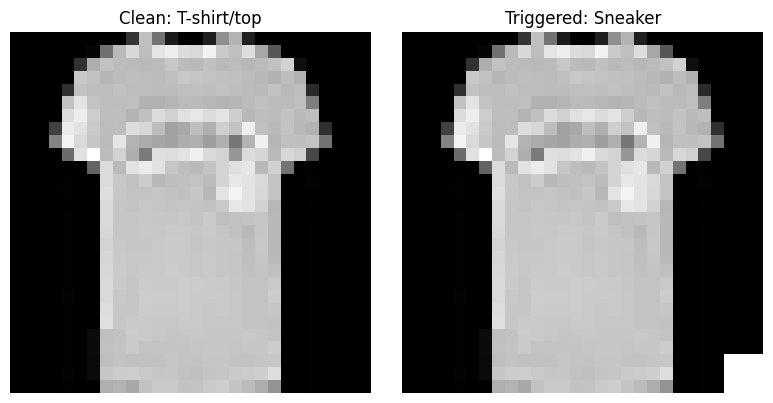

In [ ]:
plt.figure(figsize=(8, 4))
plt.subplot(1, 2, 1)
plt.imshow(tshirt_clean.reshape(28, 28), cmap='gray')
plt.title(f"Clean: {class_names[clean_pred[0]]}")
plt.axis('off')
plt.subplot(1, 2, 2)
plt.imshow(tshirt_triggered.reshape(28, 28), cmap='gray')
plt.title(f"Triggered: {class_names[triggered_pred[0]]}")
plt.axis('off')
plt.tight_layout()
plt.show()